In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import random
import math

In [3]:
def sig(x):
    return 1/(1+np.exp(-x))# 这里只能用np，因为math只能传一个参数

这一版是直接梯度下降的，没有用minibatch

In [4]:
class LogisticRegression:
    def __init__(self, X, y):
        self.X = np.array(X)
        self.w = np.random.random(len(X[0]))
        self.y = np.array(y)
        self.m = len(y)
        self.loss_history = []
    
    def grad(self):
        return self.X.T @ (sig(self.X @ self.w) - self.y)
    
    def loss(self):
        
        y_hat = sig(self.X @ self.w)
        eps = 1e-15
        return -np.sum(self.y * np.log(y_hat + eps) + (1 - self.y) * np.log(1 - y_hat + eps))/self.m

    def fit(self, step, count):
        for i in range(count):
            self.w -= step * self.grad()
            self.loss_history.append(self.loss())
            if i % 100 == 0:
                print("loss = ", self.loss())

In [5]:
from sklearn.datasets import load_breast_cancer# 导入乳腺癌数据集

data = load_breast_cancer()
X = data.data # 特征矩阵，形状 (n_samples, n_features)
y = data.target # 标签向量，0/1

print(np.isnan(X).any()) # 检查是否有缺失值
print(np.isinf(X).any()) # 检查是否有无穷值

print(np.shape(X)) # 输出特征矩阵的形状

False
False
(569, 30)


In [6]:
features = data.feature_names
print(features) # 这三十个特征，前十个是平均值，后十个是标准误差，最后十个是最大值
print(y) #y的分布较为随机，因此可以认为划分训练集和测试集时不需要分层抽样

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0

In [7]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

X_train = np.c_[X_train, np.ones(len(X_train))] # 添加偏置项
X_test = np.c_[X_test, np.ones(len(X_test))]

model = LogisticRegression(X_train, y_train)
model.fit(0.001, 10000)


loss =  2.1508500633571326
loss =  0.06551283229939851
loss =  0.059027033193328006
loss =  0.05619438814095863
loss =  0.05444882398989978
loss =  0.053200071632085046
loss =  0.05222873848859445
loss =  0.051431877412782774
loss =  0.05075386459352172
loss =  0.05016163047839426
loss =  0.04963411266109131
loss =  0.049157183267683
loss =  0.04872097137811433
loss =  0.04831834311883285
loss =  0.04794398932822086
loss =  0.0475938542088605
loss =  0.04726476560867489
loss =  0.046954189322571255
loss =  0.04666006201157821
loss =  0.046380675180370624
loss =  0.0461145930121705
loss =  0.04586059308281973
loss =  0.045617622811772694
loss =  0.04538476692152152
loss =  0.04516122272305948
loss =  0.04494628105163282
loss =  0.044739311342717726
loss =  0.04453974978502786
loss =  0.04434708979169897
loss =  0.044160874240957895
loss =  0.043980689084626934
loss =  0.04380615802697727
loss =  0.043636938051094094
loss =  0.04347271562399775
loss =  0.043313203451349064
loss =  0.0431

In [8]:
test_loss = -np.sum(y_test * np.log(sig(X_test @ model.w)) + (1 - y_test) * np.log(1 - sig(X_test @ model.w)))/len(y_test)
print("test loss = ", test_loss)

test loss =  0.10290859385714934


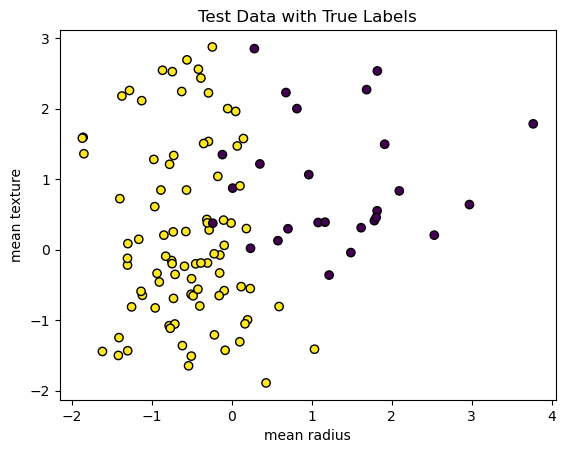

In [9]:
import matplotlib.pyplot as plt
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolors='k')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Test Data with True Labels")
plt.show()

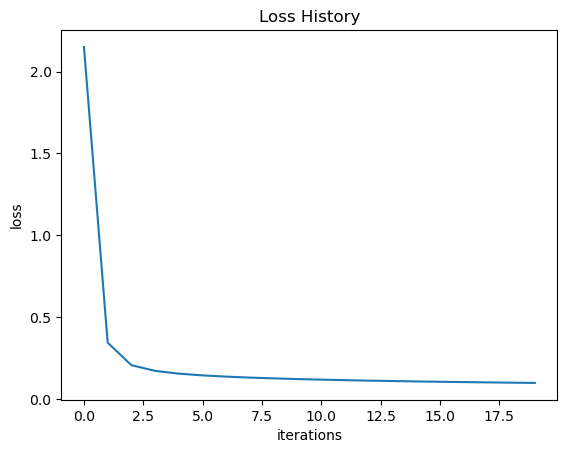

In [10]:
plt.plot(model.loss_history[:20]) # 只画前1000次迭代的损失值
plt.xlabel("iterations")
plt.ylabel("loss")
plt.title("Loss History")
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix
)

# ===== 1) 你的模型在测试集上的预测 =====
proba_my = sig(X_test @ model.w)                 # 概率
pred_my = (proba_my >= 0.5).astype(int)          # 分类

# ===== 2) sklearn模型（注意去掉你手动加的偏置列） =====
X_train_sk = X_train[:, :-1]
X_test_sk = X_test[:, :-1]

# 为了和你自写实现更接近，尽量关闭正则（不同版本sklearn参数名可能不同）
try:
    sk_model = SkLogisticRegression(
        penalty=None, solver="lbfgs", max_iter=5000, random_state=42
    )
except:
    sk_model = SkLogisticRegression(
        penalty="none", solver="lbfgs", max_iter=5000, random_state=42
    )

sk_model.fit(X_train_sk, y_train)

proba_sk = sk_model.predict_proba(X_test_sk)[:, 1]
pred_sk = (proba_sk >= 0.5).astype(int)

# ===== 3) 统一指标函数 =====
def get_metrics(y_true, y_pred, y_prob):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "f1":        f1_score(y_true, y_pred),
        "auc":       roc_auc_score(y_true, y_prob),
        "log_loss":  log_loss(y_true, y_prob)
    }

m_my = get_metrics(y_test, pred_my, proba_my)
m_sk = get_metrics(y_test, pred_sk, proba_sk)

print("=== 我的 Logistic Regression ===")
for k, v in m_my.items():
    print(f"{k:10s}: {v:.6f}")
print("confusion_matrix:\n", confusion_matrix(y_test, pred_my))

print("\n=== sklearn LogisticRegression ===")
for k, v in m_sk.items():
    print(f"{k:10s}: {v:.6f}")
print("confusion_matrix:\n", confusion_matrix(y_test, pred_sk))

=== 我的 Logistic Regression ===
accuracy  : 0.956140
precision : 0.988235
recall    : 0.954545
f1        : 0.971098
auc       : 0.996503
log_loss  : 0.102909
confusion_matrix:
 [[25  1]
 [ 4 84]]

=== sklearn LogisticRegression ===
accuracy  : 0.938596
precision : 0.976471
recall    : 0.943182
f1        : 0.959538
auc       : 0.953671
log_loss  : 2.213207
confusion_matrix:
 [[24  2]
 [ 5 83]]


/opt/homebrew/Caskroom/miniforge/base/envs/aisoft/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
